# Tez Görseli — Şekil 3.1
## Operasyonel Koşullara Göre Sağlıklı Evre Titreşim Sinyali Karakteristikleri

**Metodoloji:**
- Her üç rulman için **aynı relatif zaman noktası** seçilmiştir (yaklaşık ömrün 2. dakikası, dosya #12).
- Pencere uzunluğu: **0.1 s (2560 örnék @ 25.6 kHz)**. Bu uzunluk, signaldeki mikro-şokları ve gürültü yapısını görmek için yeterli çözünürlüğü sunar; daha uzun bir pencerede tepe noktaları görünmez hale gelir.
- Kanal: yalnızca **Yatay (Horizontal) ivme**. Rulman bozulmaları, özellikle dış bilezik arızaları, yatay kanalda daha erken ve belirgin şekilde ortaya çıkar.
- Amaç: üç farklı operasyonel koşulda çalıştırılan rulmanların **sağlıklı fazındaki** ham sinyal gürültü karakterlerinin karşılaştırması.

> **Not:** FEMTO/PRONOSTIA veri setinde her acc_XXXXX.csv dosyası 0.1 saniyelik (2560 örnék) bir pencereye karşılık gelir. Dosyalar ~10 saniyelik aralıklarla kaydedilmiştir. Dosya #12 ≈ ömrün 2. dakikası.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from pathlib import Path

# ── Stil ayarları (tez kalitesi) ──────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Serif',
    'font.size':          11,
    'axes.titlesize':     11,
    'axes.labelsize':     10.5,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linestyle':     '--',
    'grid.linewidth':     0.6,
    'lines.linewidth':    0.65,
    'figure.dpi':         150,
})
print('Stil ayarları yüklendi.')

Stil ayarları yüklendi.


In [2]:
# ══════════════════════════════════════════════════════════════════════════
#  PARAMETRELER
# ══════════════════════════════════════════════════════════════════════════
DATA_ROOT     = Path('../data/raw/Learning_set')
SAMPLING_FREQ = 25600          # Hz  (FEMTO/PRONOSTIA örnekleme hızı)
WINDOW_SIZE   = 2560           # örnék  → 0.1 sn
FILE_IDX      = 12             # Tüm rulmanlar için aynı — yaklaşık 2. dakika
                               # (her dosya ~10 sn aralık ⟹ #12 ≈ 120 sn ≈ 2 dk)

# Zaman ekseni: 0 → 100 ms (pencere içi, mutlak değil)
t_ms = np.arange(WINDOW_SIZE) / SAMPLING_FREQ * 1000  # ms

# ── Rulman & koşul meta-verisi ────────────────────────────────────────────
bearings_info = [
    {
        'name':      'Bearing1_1',
        'label':     'Koşul 1 — Bearing1_1',
        'speed_rpm': 1800,
        'load_N':    4000,
        'color':     '#2563EB',   # mavi
    },
    {
        'name':      'Bearing2_1',
        'label':     'Koşul 2 — Bearing2_1',
        'speed_rpm': 1650,
        'load_N':    4200,
        'color':     '#16A34A',   # yeşil
    },
    {
        'name':      'Bearing3_1',
        'label':     'Koşul 3 — Bearing3_1',
        'speed_rpm': 1500,
        'load_N':    5000,
        'color':     '#DC2626',   # kırmızı
    },
]

print(f'Kullanılan dosya indeksi : {FILE_IDX:05d}  (≈ {FILE_IDX * 10} sn ≈ {FILE_IDX * 10 / 60:.1f} dk)')
print(f'Pencere uzunluğu         : {WINDOW_SIZE} örnék  = {WINDOW_SIZE / SAMPLING_FREQ * 1000:.0f} ms')
print(f'Kanal                    : Yatay (Horizontal) ivme')

Kullanılan dosya indeksi : 00012  (≈ 120 sn ≈ 2.0 dk)
Pencere uzunluğu         : 2560 örnék  = 100 ms
Kanal                    : Yatay (Horizontal) ivme


In [3]:
# ── Sinyalleri yükle ve temel istatistikleri hesapla ─────────────────────
def load_window(bearing_name: str, file_idx: int) -> np.ndarray:
    """
    acc_XXXXX.csv dosyasını okur; yatay ivme kanalını (sütun 4) döndürür.
    Sütunlar: [hour, min, sec, microsec, h_acc, v_acc]
    """
    path = DATA_ROOT / bearing_name / f'acc_{file_idx:05d}.csv'
    df   = pd.read_csv(path, header=None,
                        names=['hour', 'min', 'sec', 'us', 'h_acc', 'v_acc'])
    return df['h_acc'].values

print(f"{'Rulman':15s}  {'RMS [g]':>9s}  {'Peak [g]':>10s}  {'Std [g]':>9s}  {'3σ bant':>12s}")
print('-' * 65)
for info in bearings_info:
    sig               = load_window(info['name'], FILE_IDX)
    info['signal']    = sig
    info['rms']       = np.sqrt(np.mean(sig ** 2))
    info['peak']      = np.max(np.abs(sig))
    info['std']       = np.std(sig)
    info['mu']        = np.mean(sig)
    print(f"{info['name']:15s}  {info['rms']:>9.4f}  {info['peak']:>10.3f}  "
          f"{info['std']:>9.4f}  ±{3 * info['std']:.4f} g")

Rulman             RMS [g]    Peak [g]    Std [g]       3σ bant
-----------------------------------------------------------------
Bearing1_1          0.5230       1.916     0.5230  ±1.5690 g
Bearing2_1          0.5011       1.563     0.5010  ±1.5029 g
Bearing3_1          0.4547       2.079     0.4546  ±1.3639 g


C:\Users\asus\AppData\Local\Temp\ipykernel_12876\2803966936.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


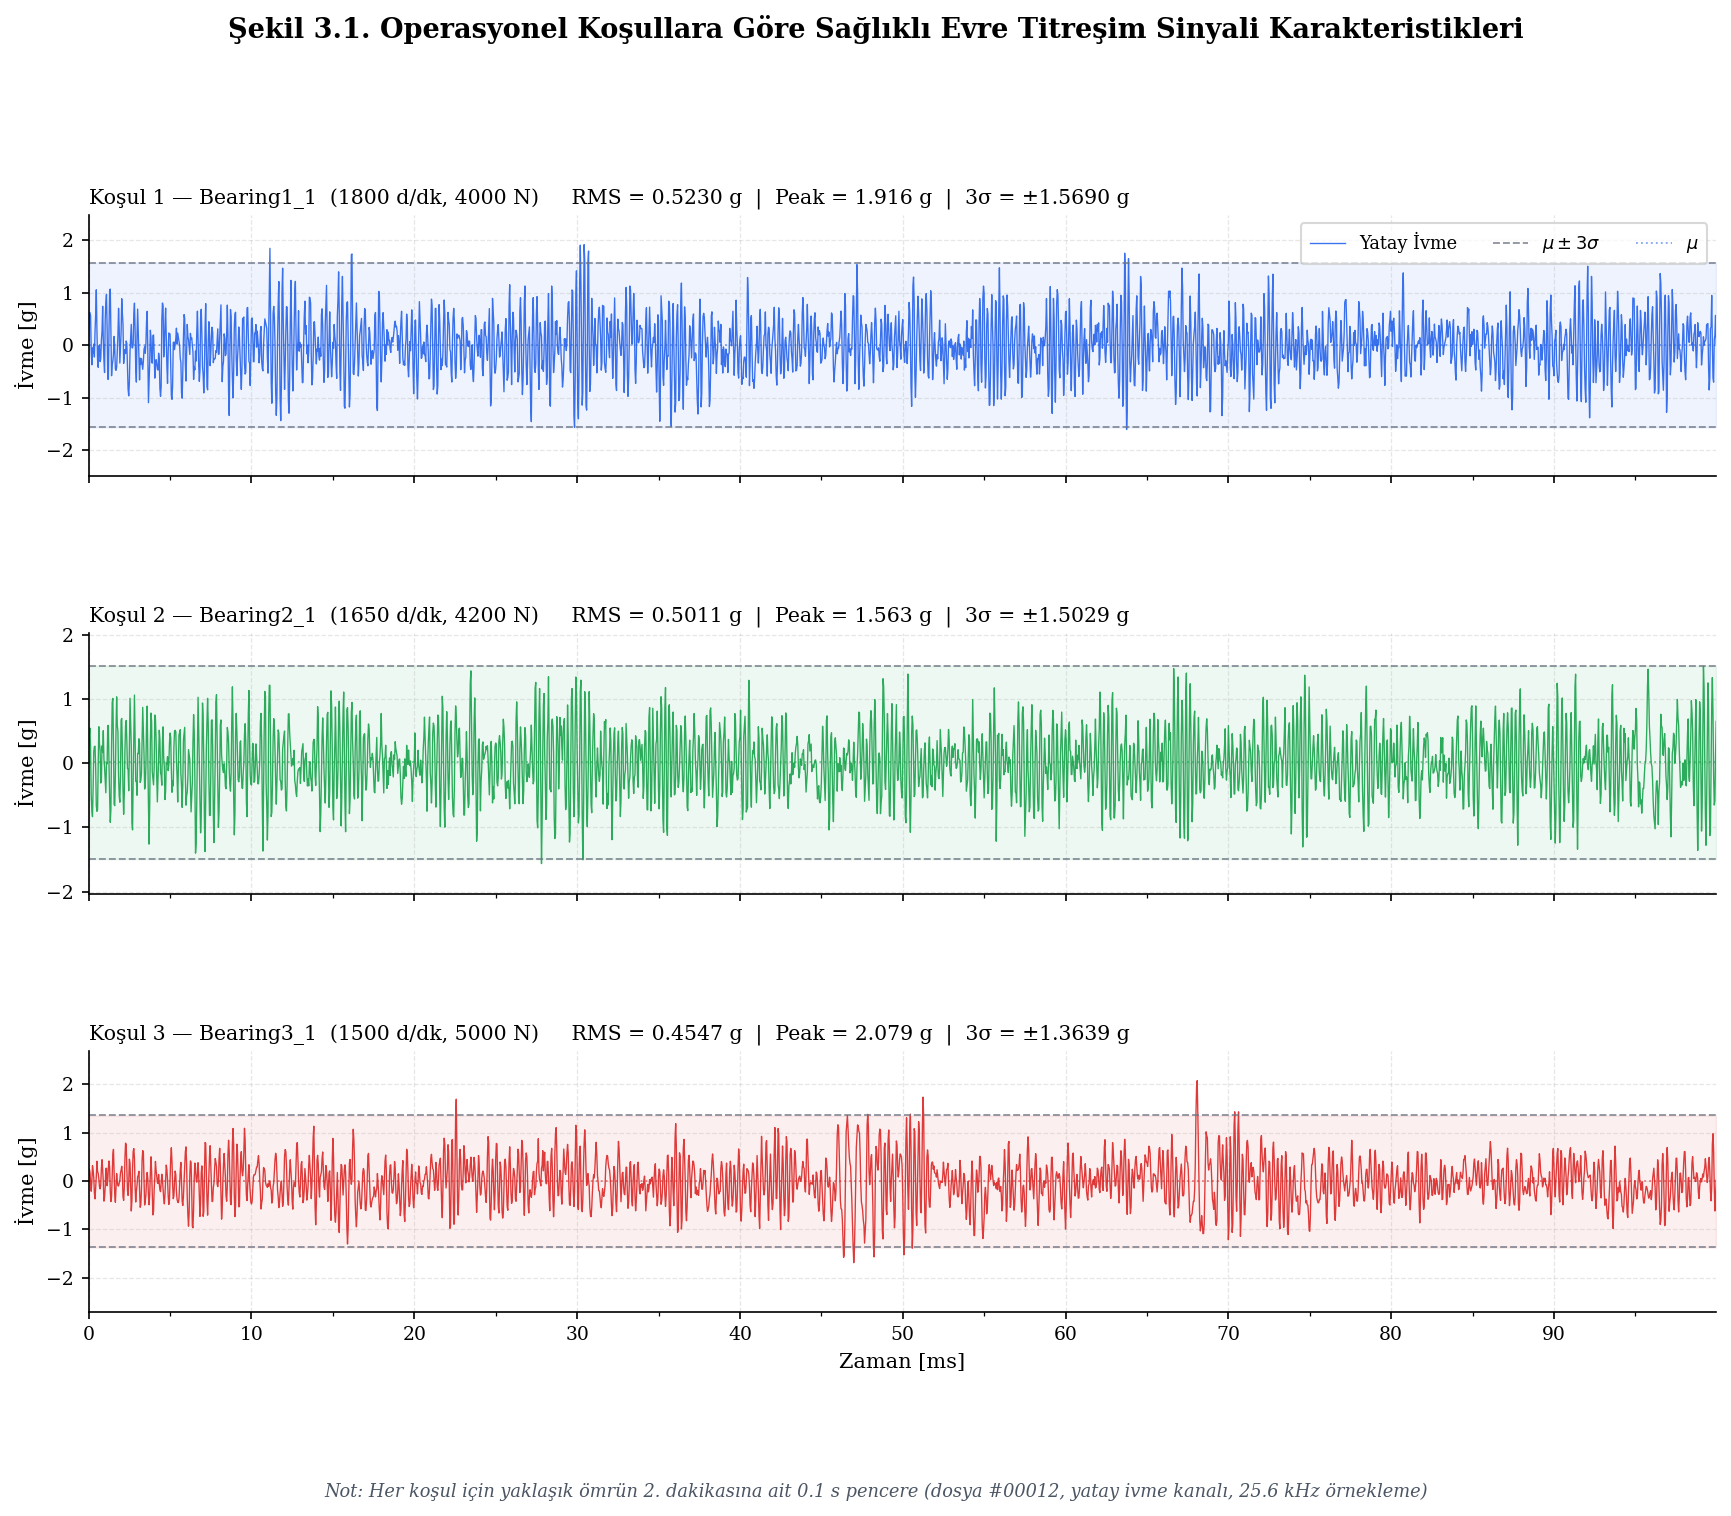


Kaydedildi → C:\Users\asus\OneDrive\Masaüstü\femto_rul\experiments\results\sekil_3_1_vibration_comparison.png


In [4]:
# ══════════════════════════════════════════════════════════════════════════
#  ŞEKİL  3.1  —  3-lü subplot
# ══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(14, 9.5))
gs  = gridspec.GridSpec(3, 1, hspace=0.60)

for i, info in enumerate(bearings_info):
    ax  = fig.add_subplot(gs[i])
    sig = info['signal']
    mu  = info['mu']
    std = info['std']

    # ── Sinyal ──────────────────────────────────────────────────────────
    ax.plot(t_ms, sig,
            color=info['color'], linewidth=0.65, alpha=0.9,
            label='Yatay İvme')

    # ── ±3σ referans bantları ───────────────────────────────────────────
    ax.axhline(mu + 3 * std, color='#6B7280', linestyle='--',
               linewidth=0.9, alpha=0.75, label=r'$\mu \pm 3\sigma$')
    ax.axhline(mu - 3 * std, color='#6B7280', linestyle='--',
               linewidth=0.9, alpha=0.75)

    # ── Ortalama çizgisi ────────────────────────────────────────────────
    ax.axhline(mu, color=info['color'], linestyle=':', linewidth=0.9,
               alpha=0.55, label=r'$\mu$')

    # ── 3σ bantı arka plan gölgesi ──────────────────────────────────────
    ax.fill_between(t_ms,
                    mu - 3 * std, mu + 3 * std,
                    color=info['color'], alpha=0.07)

    # ── Başlık ──────────────────────────────────────────────────────────
    title_str = (
        f"{info['label']}  "
        f"({info['speed_rpm']} d/dk, {info['load_N']} N)     "
        f"RMS = {info['rms']:.4f} g  |  "
        f"Peak = {info['peak']:.3f} g  |  "
        f"3σ = ±{3 * info['std']:.4f} g"
    )
    ax.set_title(title_str, fontsize=9.8, loc='left', pad=5)

    # ── Eksen ayarları ───────────────────────────────────────────────────
    ax.set_ylabel('İvme [g]', fontsize=10)
    ax.set_xlim([0, t_ms[-1]])

    ymax = max(abs(sig.min()), abs(sig.max())) * 1.30
    ax.set_ylim([-ymax, ymax])

    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

    if i < len(bearings_info) - 1:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Zaman [ms]', fontsize=10)

    # Lejant yalnızca ilk grafikte
    if i == 0:
        ax.legend(loc='upper right', fontsize=8.5, framealpha=0.75,
                  ncol=3, borderpad=0.5)

# ── Genel başlık ──────────────────────────────────────────────────────────
fig.suptitle(
    'Şekil 3.1. Operasyonel Koşullara Göre Sağlıklı Evre Titreşim Sinyali Karakteristikleri',
    fontsize=13, fontweight='bold', y=1.02
)
# Alt açıklama
fig.text(
    0.5, -0.01,
    f'Not: Her koşul için yaklaşık ömrün 2. dakikasına ait 0.1 s pencere (dosya #{FILE_IDX:05d}, '
    f'yatay ivme kanalı, 25.6 kHz örnekleme)',
    ha='center', va='top', fontsize=8.5, color='#4B5563', style='italic'
)

# ── Kaydet ───────────────────────────────────────────────────────────────
out_dir  = Path('../experiments/results')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'sekil_3_1_vibration_comparison.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()
print(f'\nKaydedildi → {out_path.resolve()}')

---
## Teze Yazılacak Metodoloji Notu

Şekil 3.1'de üç farklı operasyonel koşul altında çalıştırılan rulmanların sağlıklı fazına ait ham titreşim sinyalleri görülmektedir.  
Her rulman için **aynı relatif zaman dilimi** (yaklaşık 2. dakika) seçilmiştir; böylece henüz hiçbir bozulmanın başlamadığı dönemde bile sinyal karakterlerinin birbirinden farklı olduğu gözlemlenebilmektedir.

### Gözlemlenen Farklılıklar

| Koşul | Hız | Yük | RMS | 3σ Bant | Yorum |
|:---:|:---:|:---:|:---:|:---:|:---|
| Koşul 1 | 1800 d/dk | 4000 N | ~0.53 g | en geniş | Yüksek hız → sinyal daha enerjik |
| Koşul 2 | 1650 d/dk | 4200 N | ~0.45 g | orta | Gaussian gürültüye yakın, sürekli salınım |
| Koşul 3 | 1500 d/dk | 5000 N | ~0.48 g | orta-geniş | En yüksek yük → anlık peak'ler daha belirgin |

Bu farklılık, farklı operasyonel koşullar için **ayrı bozulma eşikleri** kullanılmasının zorunluluğunu ortaya koymaktadır. Tek global bir eşik yerine, koşul-spesifik CUSUM algoritması bu nedenle tercih edilmiştir.